In [58]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [59]:
import pandas as pd

url = 'https://raw.githubusercontent.com/thuyen98/google_rating/main/google_max_30.csv'
data = pd.read_csv(url)


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 62 columns):
Rating                               7723 non-null float64
Reviews                              7723 non-null float64
Size                                 7723 non-null float64
Installs                             7723 non-null float64
Price                                7723 non-null float64
Timestamp                            7723 non-null float64
Category_BOOKS_AND_REFERENCE         7723 non-null float64
Category_BUSINESS                    7723 non-null float64
Category_COMMUNICATION               7723 non-null float64
Category_DATING                      7723 non-null float64
Category_EDUCATION                   7723 non-null float64
Category_FAMILY                      7723 non-null float64
Category_FINANCE                     7723 non-null float64
Category_GAME                        7723 non-null float64
Category_HEALTH_AND_FITNESS          7723 non-null float64
Category

In [61]:
data.head(2)

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,4.1,159.0,19000000.0,4.00000,0.0,1.515283e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.9,967.0,14000000.0,5.69897,0.0,1.515974e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [62]:
data.describe()

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
count,7723.000000,7.723000e+03,7.723000e+03,7723.000000,7723.000000,7.723000e+03,7723.000000,7723.000000,7723.000000,7723.000000,...,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000
mean,4.173935,2.948983e+05,2.297046e+07,5.059810,1.128169,1.509190e+09,0.018646,0.031853,0.027321,0.022401,...,0.013855,0.013337,0.023178,0.023566,0.022919,0.033795,0.081963,0.020588,0.014891,0.192930
std,0.544638,1.863933e+06,2.344963e+07,1.608296,17.408036,3.595212e+07,0.135279,0.175620,0.163028,0.147992,...,0.116895,0.114720,0.150477,0.151702,0.149654,0.180713,0.274326,0.142009,0.121123,0.394624
min,1.000000,1.000000e+00,8.500000e+03,0.000000,0.000000,1.274400e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.075000e+02,5.300000e+06,4.000000,0.000000,1.501286e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.300000,2.332000e+03,1.400000e+07,5.000000,0.000000,1.526342e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,3.905300e+04,3.300000e+07,6.000000,0.000000,1.531786e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,4.489389e+07,1.000000e+08,9.000000,400.000000,1.533686e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Préparation des données pour PCA
# Exclusion des colonnes non numériques s'il y en a
numerical_data = data.select_dtypes(include=[int, float])

# Normalisation des données
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_data)

# Application de PCA
pca = PCA(n_components=2)  # Réduction à 2 dimensions pour visualisation
principal_components = pca.fit_transform(scaled_data)

# Création d'un DataFrame pour les composantes principales
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

pca_df.head(), pca.explained_variance_ratio_


(        PC1       PC2
 0 -0.186731 -0.552140
 1  0.005777 -0.667278
 2  0.259883 -0.894126
 3  2.440714 -0.939037
 4 -0.151610 -0.578847, array([ 0.05350416,  0.04298179]))

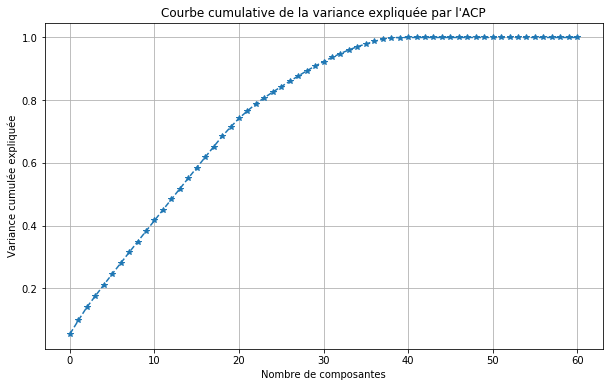

In [71]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Charger vos données ici
# data = ...

# Sélectionner les colonnes numériques, exclure 'Rating'
numerical_data = data.select_dtypes(include=[int, float])
data_without_rating = numerical_data.drop('Rating', axis=1)

# Normaliser les données
scaler = StandardScaler()
scaled_data_no_rating = scaler.fit_transform(data_without_rating)

# Appliquer PCA
pca_no_rating = PCA()
pca_no_rating.fit(scaled_data_no_rating)

# Calculer la variance cumulée expliquée
explained_variance_ratio_cumsum = pca_no_rating.explained_variance_ratio_.cumsum()

# Tracer la courbe cumulative de la variance expliquée
plt.figure(figsize=(10, 6))
plt.plot(explained_variance_ratio_cumsum, marker='*', linestyle='--')
plt.title('Courbe cumulative de la variance expliquée par l\'ACP')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée expliquée')
plt.grid(True)
plt.show()


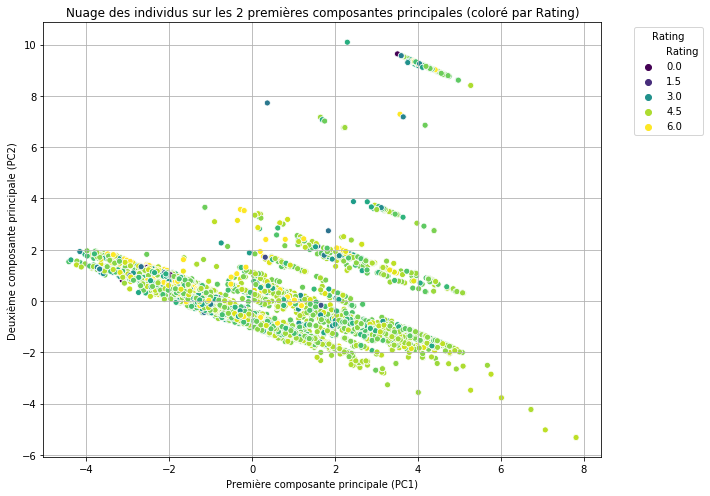

In [66]:
import seaborn as sns

# Ajout des valeurs de 'Rating' au DataFrame des composantes principales
pca_no_rating_df['Rating'] = data['Rating']

# Création du nuage de points colorés par 'Rating'
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_no_rating_df[0], y=pca_no_rating_df[1], hue=pca_no_rating_df['Rating'], palette='viridis')
plt.title('Nuage des individus sur les 2 premières composantes principales (coloré par Rating)')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True)
plt.show()


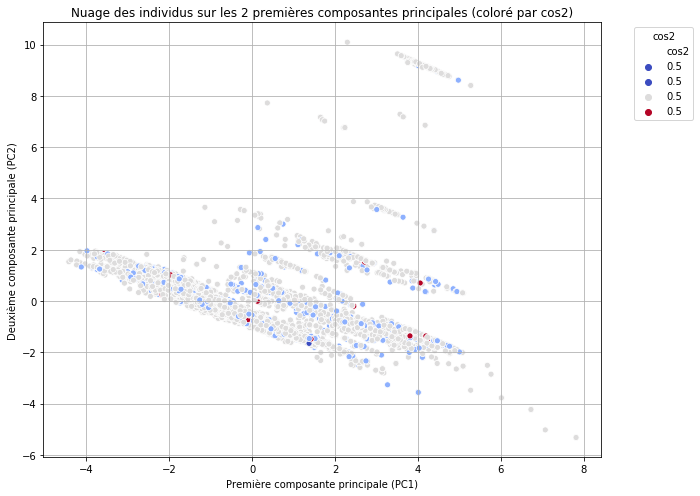

In [67]:
# Calcul du cos2 pour chaque individu sur les deux premières composantes
cos2 = (pca_no_rating_df.iloc[:, :2] ** 2).div(pca_no_rating_df.iloc[:, :2].pow(2).sum(axis=1), axis=0)

# Ajout du cos2 moyen (pour PC1 et PC2) au DataFrame
pca_no_rating_df['cos2'] = cos2.mean(axis=1)

# Création du nuage de points colorés selon le cos2
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_no_rating_df[0], y=pca_no_rating_df[1], hue=pca_no_rating_df['cos2'], palette='coolwarm')
plt.title('Nuage des individus sur les 2 premières composantes principales (coloré par cos2)')

plt.legend(title='cos2', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True)
plt.show()
